In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib #(That is use for save the model)
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE

In [3]:
df=pd.read_csv('Telco-Customer-Churn.csv')
df=df.drop(columns=['customerID'])

In [4]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [7]:
df['TotalCharges']=df['TotalCharges'].replace({" ":"0.0"}).astype(float)

In [8]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df['Churn'].value_counts()
print(f'Class Imbalance ratio:{df['Churn'].value_counts()[0]/df['Churn'].value_counts()[1]:.2f}:1')

Class Imbalance ratio:2.77:1


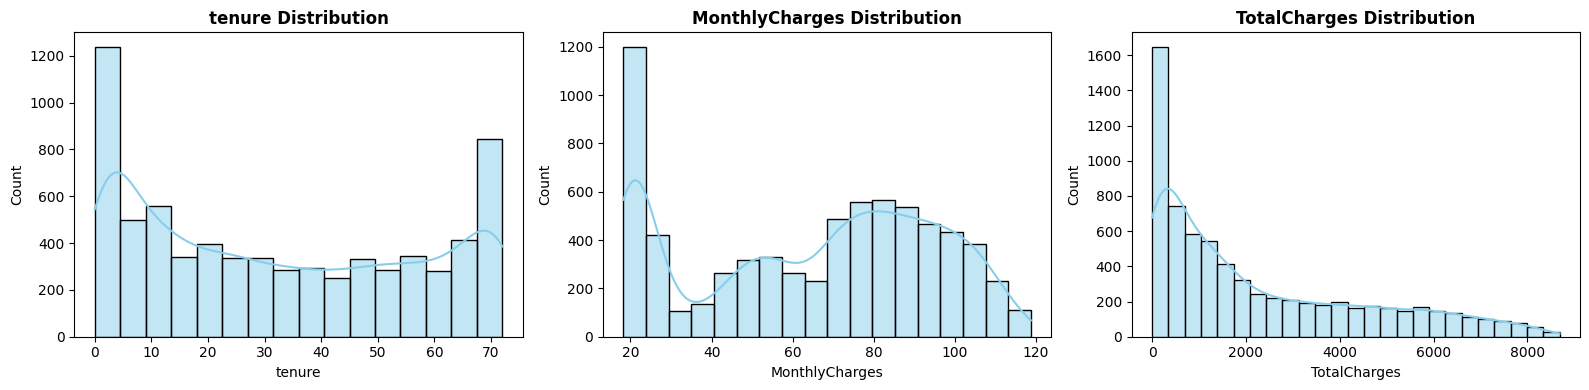

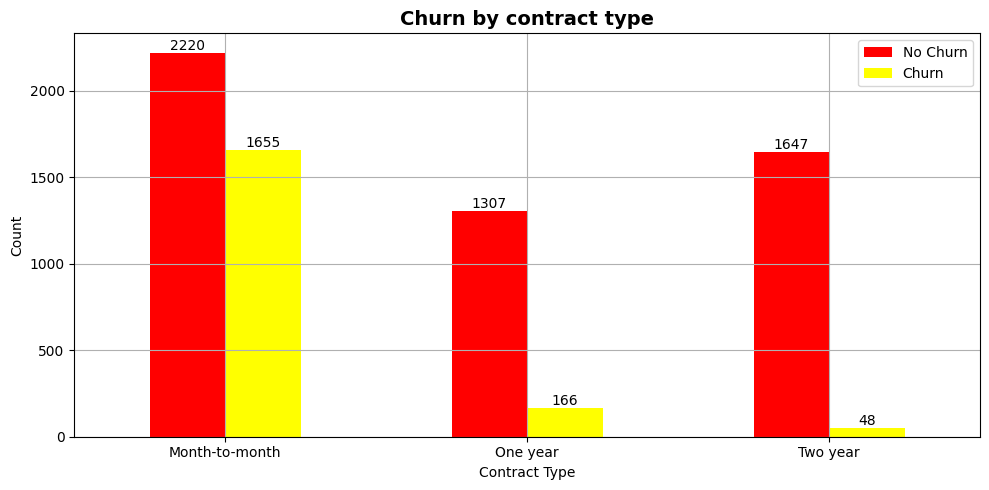

In [10]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
for i,col in enumerate(['tenure','MonthlyCharges','TotalCharges',]):
    ax=sns.histplot(df[col],kde=True,ax=axes[i],color='skyblue')
    axes[i].set_title(f'{col} Distribution',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()
#Churn By Contract


fig,ax=plt.subplots(1,1,figsize=(10,5))
contract_churn=df.groupby(['Contract','Churn']).size().unstack(fill_value=0)
contract_churn.plot(kind='bar',stacked=False,ax=ax,color=['red','yellow'])
ax.set_title('Churn by contract type',fontsize=14,fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Count')
ax.legend(['No Churn','Churn'])
ax.set_xticklabels(ax.get_xticklabels(),rotation=0)
for container in ax.containers:
    ax.bar_label(container)
ax.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# #encode binary columns
# binary_cols=['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
# for col in binary_cols:
#     df[col]=df[col].map({'Yes':1,'No':0})
# df['gender']=df['gender'].map({'Male':1,'Female':0})
# categorical_cols = ['MultipleLines','InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']
# encoders = {}
# for col in categorical_cols:
#     encoder = LabelEncoder()
#     df[col] = encoder.fit_transform(df[col])
#     encoders[col] = encoder
# Encode binary columns
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0})

df['gender'] = df['gender'].map({'Male':1,'Female':0})

# Categorical encoding
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
                    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
                    'Contract','PaymentMethod']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le   # save encoder

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [13]:
x=df.drop('Churn',axis=1)
y=df['Churn']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [14]:
x_train.shape[0]

5634

In [15]:
x_test.shape[0]

1409

In [16]:
smote=SMOTE(random_state=42)
x_train_balanced,y_train_balanced=smote.fit_resample(x_train,y_train)
dict(y_train.value_counts())

{0: np.int64(4139), 1: np.int64(1495)}

In [17]:
#After Ste
dict(pd.Series(y_train_balanced).value_counts())

{0: np.int64(4139), 1: np.int64(4139)}

In [18]:
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(x_train_balanced, y_train_balanced)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [19]:
y_train_pred=xgb_model.predict(x_train)
y_test_pred=xgb_model.predict(x_test)
train_acc=accuracy_score(y_train,y_train_pred)
test_acc=accuracy_score(y_test,y_test_pred)

In [20]:
print('Trainning Accuracy',train_acc)
print('Test accuracy',test_acc)

Trainning Accuracy 0.8258785942492013
Test accuracy 0.7686302342086586


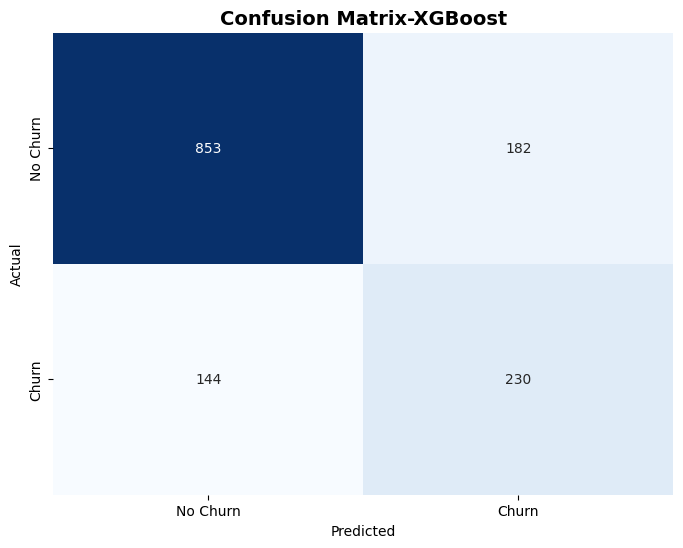

In [21]:
cm=confusion_matrix(y_test,y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,
            xticklabels=['No Churn','Churn'],yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix-XGBoost',fontsize=14,fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

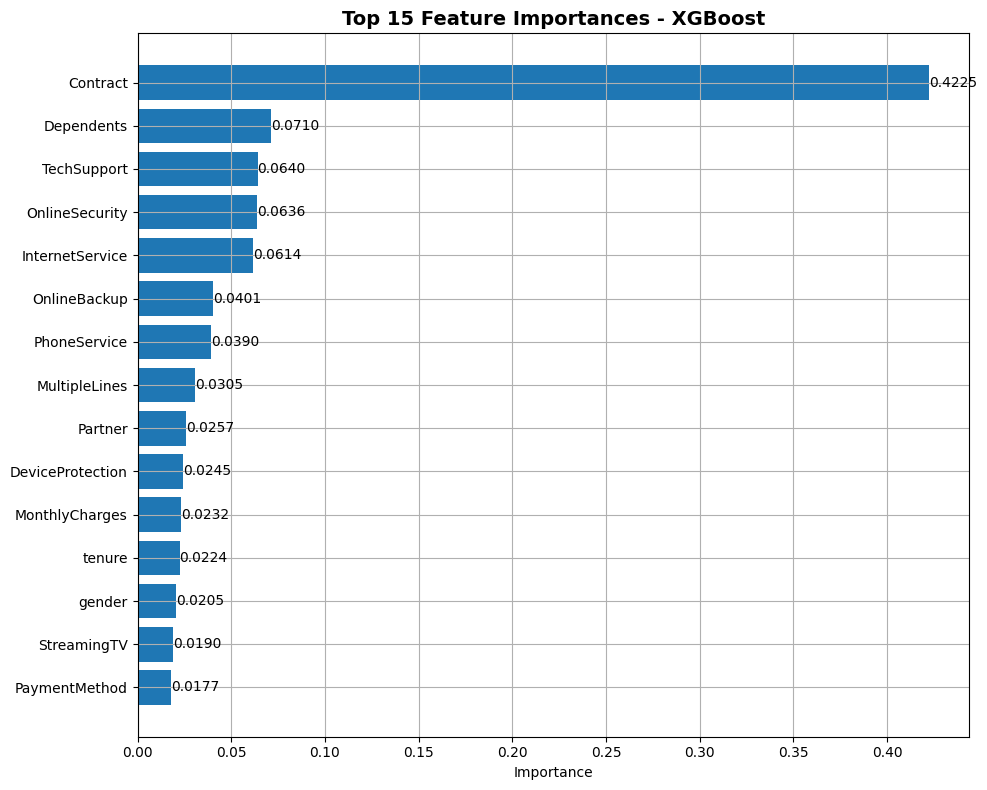

In [22]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))

bars = plt.barh(
    feature_importance['Feature'][:15],
    feature_importance['Importance'][:15]
)

plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.4f}',   # correct format
        va='center'
    )

plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
joblib.dump(xgb_model, 'customer_churn_model.pkl')
joblib.dump(encoders, 'churn_encoders.pkl')

['churn_encoders.pkl']

In [24]:
import numpy as np
import pandas as pd
import joblib

# ===============================
# LOAD MODEL & ENCODERS
# ===============================
model = joblib.load("customer_churn_model.pkl")
encoders = joblib.load("churn_encoders.pkl")

# ===============================
# USER INPUT (MATCH DATASET)
# ===============================
data = {
    'gender': [input("Gender (Male/Female): ")],
    'SeniorCitizen': [int(input("Senior Citizen (0/1): "))],
    'Partner': [input("Partner (Yes/No): ")],
    'Dependents': [input("Dependents (Yes/No): ")],
    'tenure': [int(input("Tenure (months): "))],
    'PhoneService': [input("Phone Service (Yes/No): ")],
    'MultipleLines': [input("Multiple Lines: ")],
    'InternetService': [input("Internet Service: ")],
    'OnlineSecurity': [input("Online Security: ")],
    'OnlineBackup': [input("Online Backup: ")],
    'DeviceProtection': [input("Device Protection: ")],
    'TechSupport': [input("Tech Support: ")],
    'StreamingTV': [input("Streaming TV: ")],
    'StreamingMovies': [input("Streaming Movies: ")],
    'Contract': [input("Contract Type: ")],
    'PaperlessBilling': [input("Paperless Billing (Yes/No): ")],
    'PaymentMethod': [input("Payment Method: ")],
    'MonthlyCharges': [float(input("Monthly Charges: "))],
    'TotalCharges': [float(input("Total Charges: "))]
}

# ===============================
# CREATE DATAFRAME
# ===============================
input_df = pd.DataFrame(data)

# ===============================
# APPLY SAME ENCODING
# ===============================

# Binary mapping
binary_map = {'Yes':1,'No':0}
for col in ['Partner','Dependents','PhoneService','PaperlessBilling']:
    input_df[col] = input_df[col].map(binary_map)

input_df['gender'] = input_df['gender'].map({'Male':1,'Female':0})

# Label encoding
for col, le in encoders.items():
    input_df[col] = le.transform(input_df[col])

# ===============================
# PREDICTION
# ===============================
prediction = model.predict(input_df)

print("\n===============================")
if prediction[0] == 1:
    print("📉 Output: Customer WILL CHURN")
else:
    print("📈 Output: Customer WILL NOT CHURN")
print("===============================")

Gender (Male/Female):  Male
Senior Citizen (0/1):  1
Partner (Yes/No):  Yes
Dependents (Yes/No):  Yes
Tenure (months):  23
Phone Service (Yes/No):  Yes
Multiple Lines:  No
Internet Service:  Fiber optic
Online Security:  No
Online Backup:  Yes
Device Protection:  No
Tech Support:  No
Streaming TV:  Yes
Streaming Movies:  Yes
Contract Type:  Two year
Paperless Billing (Yes/No):  Yes
Payment Method:  Mailed check
Monthly Charges:  70
Total Charges:  560



📈 Output: Customer WILL NOT CHURN
